In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("hw7.ipynb")

In [1]:
rng_seed = 32

In [2]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
#below line allows matplotlib plots to appear in cell output
%matplotlib inline

## **Question 1**: Central Limit Theorem Demonstration

### Part a: Uniform Distribution Sampling

Write a function `sample_uniform_mean(a, b, n_samples)` that samples from a uniform distribution and returns the mean of the samples.

[numpy uniform dist. docs](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html)

**Requirements:**
- Use `np.random` methods to generate samples
- Return the mean of the samples

**Parameters:**
- `a`: float, lower bound of uniform distribution
- `b`: float, upper bound of uniform distribution  
- `n_samples`: int, number of samples to draw

**Returns:**
- `sample_mean`: float, mean of the samples

In [3]:
def sample_uniform_mean(a, b, n_samples):
    # BEGIN SOLUTION NO PROMPT
    """
    Sample from a uniform distribution and return the mean of the samples.
    
    Parameters:
    -----------
    a : float
        Lower bound of uniform distribution
    b : float
        Upper bound of uniform distribution
    n_samples : int
        Number of samples to draw
    
    Returns:
    --------
    sample_mean : float
        Mean of the samples
    """
    samples = np.random.uniform(a, b, n_samples)
    sample_mean = np.mean(samples)
    return sample_mean
    # END SOLUTION
    """ # BEGIN PROMPT
    # Write your code here!
    
    return sample_mean
    """; # END PROMPT

In [ ]:
grader.check("q1a")

### Part b: Gamma Distribution Sampling

Write a function `sample_gamma_mean(shape, scale, n_samples)` that samples from a gamma distribution and returns the mean of the samples.

[numpy gamma dist. docs](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html)

**Requirements:**
- Use `np.random` to generate samples
- Return the mean of the samples

**Parameters:**
- `shape`: float, shape parameter of gamma distribution
- `scale`: float, scale parameter of gamma distribution
- `n_samples`: int, number of samples to draw

**Returns:**
- `sample_mean`: float, mean of the samples

In [6]:
def sample_gamma_mean(shape, scale, n_samples):
    # BEGIN SOLUTION NO PROMPT
    """
    Sample from a gamma distribution and return the mean of the samples.
    
    Parameters:
    -----------
    shape : float
        Shape parameter of gamma distribution
    scale : float
        Scale parameter of gamma distribution
    n_samples : int
        Number of samples to draw
    
    Returns:
    --------
    sample_mean : float
        Mean of the samples
    """
    samples = np.random.gamma(shape, scale, n_samples)
    sample_mean = np.mean(samples)
    return sample_mean
    # END SOLUTION
    """ # BEGIN PROMPT
    # Write your code here!
    return sample_mean
    """; # END PROMPT

In [ ]:
grader.check("q1b")

### Part c: Central Limit Theorem Visualization

Write a function `plot_sample_means(use_uniform, N, n_samples=100, bins=30, show_plot=False)` that demonstrates the Central Limit Theorem by plotting a histogram of sample means.

**Requirements:**
- If `use_uniform=True`, use `sample_uniform_mean(0, 10, n_samples)` for each trial
- If `use_uniform=False`, use `sample_gamma_mean(2, 2, n_samples)` for each trial
- Perform N trials to collect N sample means
- Create a histogram of the sample means with specified number of bins
- Set x-axis label to "Sample Mean"
- Set y-axis label to "Density"  
- Set title to include "Central Limit Theorem" and distribution information
- Add a grid to the plot
- The function should return the matplotlib figure object

**Parameters:**
- `use_uniform`: bool, if True use uniform distribution, else use gamma
- `N`: int, number of trials (number of sample means to collect)
- `n_samples`: int, default 100, number of samples per trial
- `bins`: int, default 30, number of histogram bins
- `show_plot`: bool, default False. If True, call `plt.show()`

**Returns:**
- `fig`: matplotlib figure object

In [9]:
def plot_sample_means(use_uniform, N, n_samples=100, bins=30, show_plot=False):
    # BEGIN SOLUTION NO PROMPT
    """
    Demonstrate the Central Limit Theorem by plotting histogram of sample means.
    
    Parameters:
    -----------
    use_uniform : bool
        If True use uniform distribution, else use gamma distribution
    N : int
        Number of trials (number of sample means to collect)
    n_samples : int, default 100
        Number of samples per trial
    bins : int, default 30
        Number of histogram bins
    show_plot : bool, default False
        If True, display the plot with plt.show()
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object containing the plot
    """
    # Collect N sample means
    sample_means = []
    
    for i in range(N):
        if use_uniform:
            mean_val = sample_uniform_mean(0, 10, n_samples)
        else:
            mean_val = sample_gamma_mean(2, 2, n_samples)
        
        sample_means.append(mean_val)
    
    sample_means = np.array(sample_means)
    
    # Determine distribution name for title
    if use_uniform:
        dist_name = "Uniform(0,10)"
    else:
        dist_name = "Gamma(2,2)"
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create histogram of sample means
    ax.hist(sample_means, bins=bins, density=True, alpha=0.7, 
            color='lightblue', edgecolor='black')
    
    # Set labels and formatting
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Density')
    ax.set_title(f'Central Limit Theorem: {dist_name}\n' +
                f'Distribution of Sample Means (N={N} trials, n={n_samples} samples each)')
    ax.grid(True, alpha=0.3)
    
    if show_plot:
        plt.show()
    
    return fig
    # END SOLUTION
    """ # BEGIN PROMPT
    #compute an array of sample means
    
    ...

    # Create histogram plot
    fig, ax = plt.subplots(figsize=(10, 6))


    ...
    
    if show_plot:
        plt.show()
    
    return fig
    """; # END PROMPT

Testing individual functions:
Sample mean from Uniform(0,10): 5.079 (theoretical: 5.0)
Sample mean from Gamma(2,2): 4.023 (theoretical: 4.0)

Demonstrating Central Limit Theorem convergence:


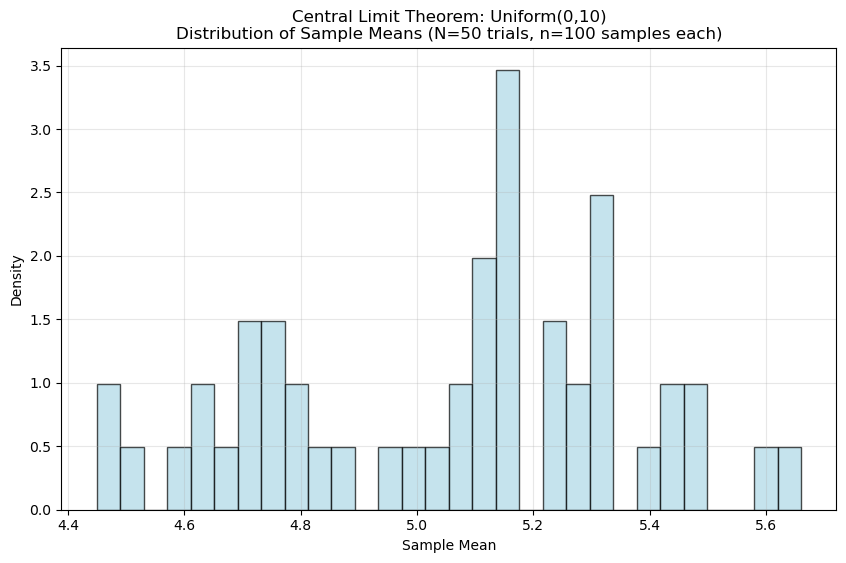

Uniform distribution with N=50 trials


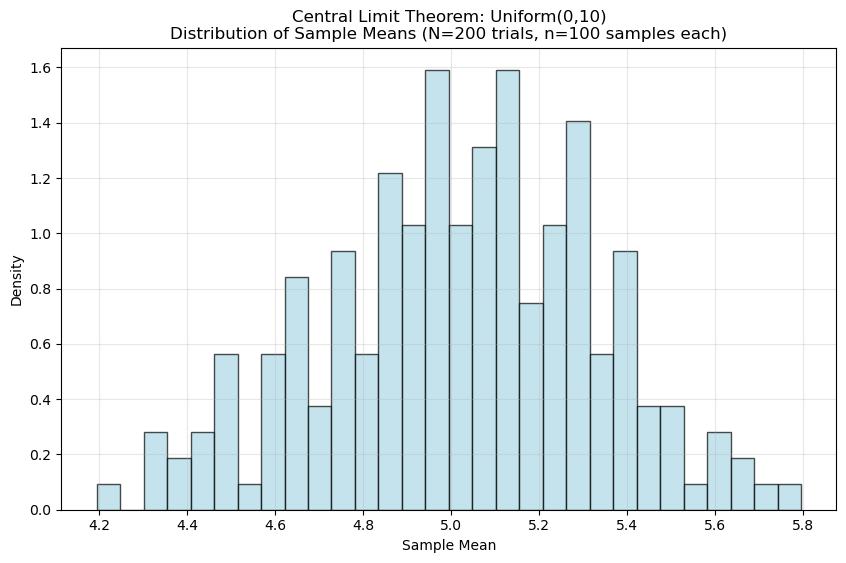

Uniform distribution with N=200 trials


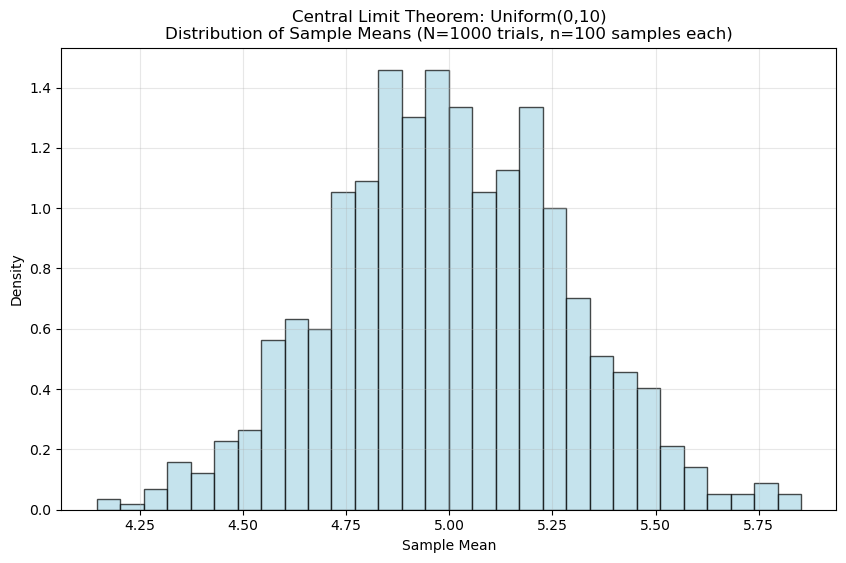

Uniform distribution with N=1000 trials


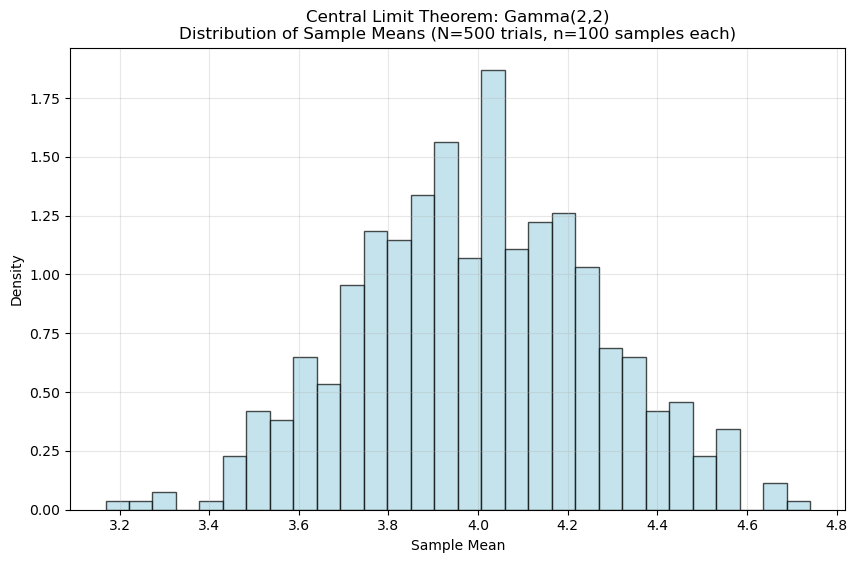

Gamma distribution with N=500 trials


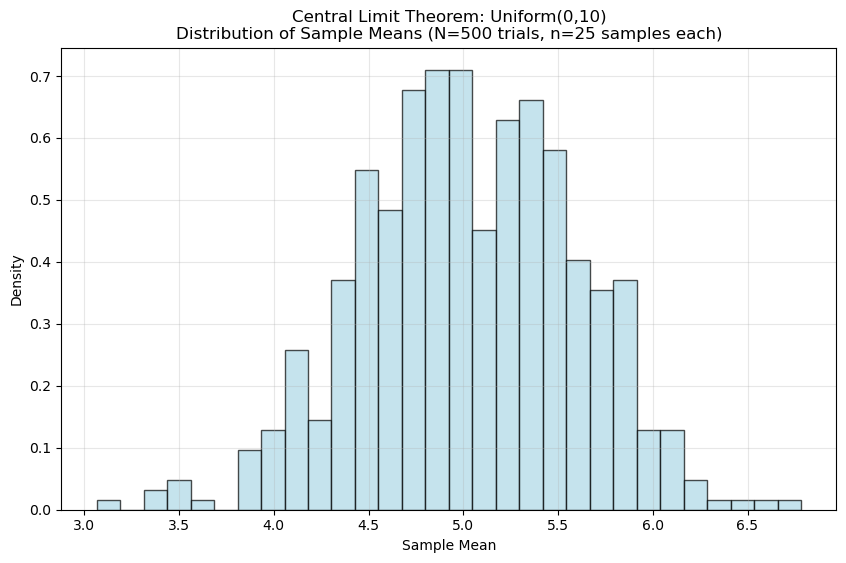

Uniform distribution with N=500 trials, n_samples=25 (wider distribution)


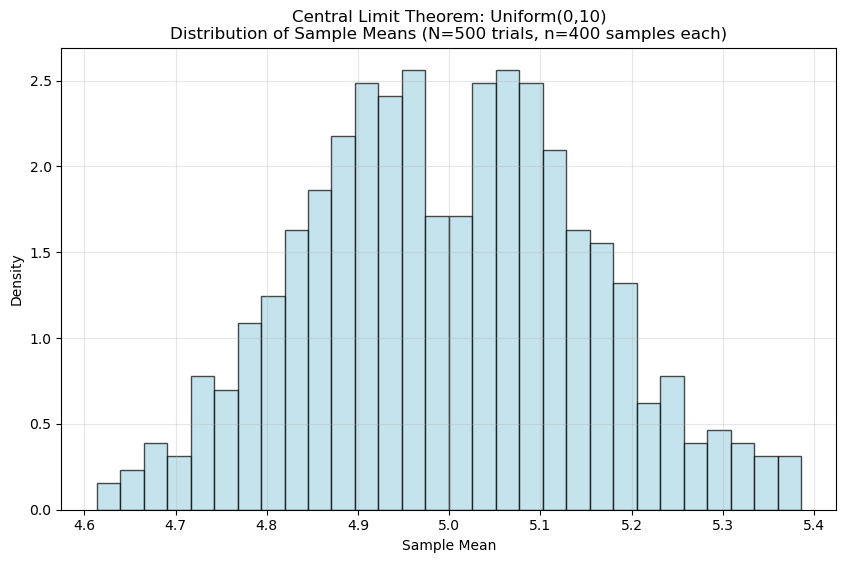

Uniform distribution with N=500 trials, n_samples=400 (narrower distribution)


In [10]:
# Test the function and demonstrate CLT convergence with different N values
np.random.seed(rng_seed)  # Set seed for reproducible results

# Test individual functions first
print("Testing individual functions:")
uniform_mean = sample_uniform_mean(0, 10, 1000)
gamma_mean = sample_gamma_mean(2, 2, 1000)
print(f"Sample mean from Uniform(0,10): {uniform_mean:.3f} (theoretical: 5.0)")
print(f"Sample mean from Gamma(2,2): {gamma_mean:.3f} (theoretical: 4.0)")

# Demonstrate CLT convergence with different N values
print("\nDemonstrating Central Limit Theorem convergence:")

# Small N - should show some deviation from normal
fig1 = plot_sample_means(use_uniform=True, N=50, n_samples=100, show_plot=True)
print("Uniform distribution with N=50 trials")

# Medium N - better convergence
fig2 = plot_sample_means(use_uniform=True, N=200, n_samples=100, show_plot=True) 
print("Uniform distribution with N=200 trials")

# Large N - clear normal distribution
fig3 = plot_sample_means(use_uniform=True, N=1000, n_samples=100, show_plot=True)
print("Uniform distribution with N=1000 trials")

# Compare gamma distribution
fig4 = plot_sample_means(use_uniform=False, N=500, n_samples=100, show_plot=True)
print("Gamma distribution with N=500 trials")

# Show effect of sample size per trial
fig5 = plot_sample_means(use_uniform=True, N=500, n_samples=25, show_plot=True)
print("Uniform distribution with N=500 trials, n_samples=25 (wider distribution)")

fig6 = plot_sample_means(use_uniform=True, N=500, n_samples=400, show_plot=True)
print("Uniform distribution with N=500 trials, n_samples=400 (narrower distribution)")

In [ ]:
grader.check("q1c")

## **Question 2**: Error Propagation

When we have a function $y = g(x_1, x_2, \ldots, x_n)$ where each parameter $x_i$ has an associated uncertainty $\sigma_i$, the propagated uncertainty in $y$ is given by:

$$\sigma_y = \sqrt{\sum_{i=1}^{n} \left(\frac{\partial g}{\partial x_i}\right)^2 \sigma_i^2}$$

This formula assumes that the uncertainties in the input parameters are uncorrelated (independent). Each partial derivative $\frac{\partial g}{\partial x_i}$ is evaluated at the measured values of all parameters.

In this question, you will implement error propagation for two different physics formulas by:
1. Computing the partial derivatives analytically
2. Implementing functions that return both the calculated value and its propagated uncertainty as a tuple `(y, sigma_y)`

### Part a: Projectile Motion Range

The range of a projectile launched at angle $\theta$ with initial velocity $v_0$ is given by:

$$R = \frac{v_0^2 \sin(2\theta)}{g}$$

where $g = 9.81$ m/s² is the acceleration due to gravity.

Write a function `projectile_range_with_error(v0, sigma_v0, theta, sigma_theta, g=9.81)` that calculates both the range and its propagated uncertainty.

**Requirements:**
- Use the error propagation formula with partial derivatives
- `theta` should be in radians
- Return a tuple `(R, sigma_R)` where `R` is the range and `sigma_R` is the propagated uncertainty

**Hint:** You'll need to compute:
$\frac{\partial R}{\partial v_0}$, $\frac{\partial R}{\partial \theta}$
and then implement the analytic expression you derive into your code

**Parameters:**
- `v0`: float, initial velocity in m/s
- `sigma_v0`: float, uncertainty in initial velocity  
- `theta`: float, launch angle in radians
- `sigma_theta`: float, uncertainty in launch angle in radians
- `g`: float, default 9.81, acceleration due to gravity in m/s²

**Returns:**
- `(R, sigma_R)`: tuple of floats, range and its uncertainty in meters

In [14]:
def projectile_range_with_error(v0, sigma_v0, theta, sigma_theta, g=9.81):
    # BEGIN SOLUTION NO PROMPT
    """
    Calculate projectile range and its propagated uncertainty.
    
    Parameters:
    -----------
    v0 : float
        Initial velocity in m/s
    sigma_v0 : float
        Uncertainty in initial velocity
    theta : float
        Launch angle in radians
    sigma_theta : float
        Uncertainty in launch angle in radians
    g : float, default 9.81
        Acceleration due to gravity in m/s²
    
    Returns:
    --------
    (R, sigma_R) : tuple of floats
        Range and its uncertainty in meters
    """
    # Calculate the range
    R = (v0**2 * np.sin(2*theta)) / g
    
    # Calculate partial derivatives
    dR_dv0 = (2*v0 * np.sin(2*theta)) / g
    dR_dtheta = (2*v0**2 * np.cos(2*theta)) / g
    
    # Apply error propagation formula
    sigma_R = np.sqrt((dR_dv0 * sigma_v0)**2 + (dR_dtheta * sigma_theta)**2)
    
    return (R, sigma_R)
    # END SOLUTION
    """ # BEGIN PROMPT
    # Calculate the range R
    R = ...
    
    # Calculate partial derivatives
    dR_dv0 = ...
    dR_dtheta = ...
    
    # Apply error propagation formula
    sigma_R = ...
    
    return (R, sigma_R)
    """; # END PROMPT

In [ ]:
grader.check("q2a")

### Part b: Physical Pendulum Period

The period of a physical pendulum (a rigid body oscillating about a pivot point) is given by:

$$T = 2\pi \sqrt{\frac{I}{mgd}}$$

where:
- $I$ is the moment of inertia about the pivot point
- $m$ is the mass of the pendulum
- $g$ is the acceleration due to gravity  
- $d$ is the distance from the pivot to the center of mass

Write a function `pendulum_period_with_error(I, sigma_I, m, sigma_m, d, sigma_d, g=9.81)` that calculates both the period and its propagated uncertainty.

**Requirements:**
- Use the error propagation formula with partial derivatives
- Return a tuple `(T, sigma_T)` where `T` is the period and `sigma_T` is the propagated uncertainty

**Hint:** You'll need to compute:
$\frac{\partial T}{\partial I}$, $\frac{\partial T}{\partial m}$, $\frac{\partial T}{\partial d}$

**Parameters:**
- `I`: float, moment of inertia in kg⋅m²
- `sigma_I`: float, uncertainty in moment of inertia
- `m`: float, mass in kg
- `sigma_m`: float, uncertainty in mass
- `d`: float, distance to center of mass in meters
- `sigma_d`: float, uncertainty in distance
- `g`: float, default 9.81, acceleration due to gravity in m/s²

**Returns:**
- `(T, sigma_T)`: tuple of floats, period and its uncertainty in seconds

In [18]:
def pendulum_period_with_error(I, sigma_I, m, sigma_m, d, sigma_d, g=9.81):
    # BEGIN SOLUTION NO PROMPT
    """
    Calculate physical pendulum period and its propagated uncertainty.
    
    Parameters:
    -----------
    I : float
        Moment of inertia in kg⋅m²
    sigma_I : float
        Uncertainty in moment of inertia
    m : float
        Mass in kg
    sigma_m : float
        Uncertainty in mass
    d : float
        Distance to center of mass in meters
    sigma_d : float
        Uncertainty in distance
    g : float, default 9.81
        Acceleration due to gravity in m/s²
    
    Returns:
    --------
    (T, sigma_T) : tuple of floats
        Period and its uncertainty in seconds
    """
    # Calculate the period
    T = 2 * np.pi * np.sqrt(I / (m * g * d))
    
    # Calculate partial derivatives
    dT_dI = np.pi / np.sqrt(I * m * g * d)
    dT_dm = -np.pi * np.sqrt(I) / (m**(3/2) * np.sqrt(g * d))
    dT_dd = -np.pi * np.sqrt(I) / (d**(3/2) * np.sqrt(m * g))
    
    # Apply error propagation formula
    sigma_T = np.sqrt((dT_dI * sigma_I)**2 + (dT_dm * sigma_m)**2 + (dT_dd * sigma_d)**2)
    
    return (T, sigma_T)
    # END SOLUTION
    """ # BEGIN PROMPT
    # Calculate the period T
    T = ...
    
    # Calculate partial derivatives
    dT_dI = ...
    dT_dm = ...
    dT_dd = ...
    
    # Apply error propagation formula
    sigma_T = ...
    
    return (T, sigma_T)
    """; # END PROMPT

In [ ]:
grader.check("q2b")

## **Question 3**: Covariance and Correlation Analysis

Covariance and correlation are fundamental measures of how two variables change together. For a dataset with multiple variables, we can compute:

**Covariance Matrix**: $\text{Cov}(X_i, X_j) = \frac{1}{n-1} \sum_{k=1}^{n} (X_{i,k} - \bar{X_i})(X_{j,k} - \bar{X_j})$

**Correlation Matrix**: $\text{Corr}(X_i, X_j) = \frac{\text{Cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}}$

Where correlation values range from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear correlation.

In this question, you will analyze a physics dataset containing 7 variables that represent related physical quantities. Some variables should show strong correlations based on physical laws, while others should be relatively independent.

### Part a: Computing Covariance and Correlation Matrices

Write a function `analyze_covariance(filename)` that reads a CSV data file and computes both the covariance and correlation matrices.

**Requirements:**
- Read the CSV file using pandas (`pd.read_csv`)
- Compute the covariance matrix using numpy (sample covariance with n-1 denominator) (you can also do this by hand, but numpy is much easier/faster)
- Compute the correlation matrix using numpy
- Return both matrices as numpy arrays

**Parameters:**
- `filename`: str, csv filename (`physics_data.csv`)

**Returns:**
- `(cov_matrix, corr_matrix)`: tuple of numpy arrays
  - `cov_matrix`: covariance matrix (7x7)
  - `corr_matrix`: correlation matrix (7x7)

**Note:** The correlation matrix should have 1.0 on the diagonal and values between -1 and 1 elsewhere.

In [22]:
def analyze_covariance(filename):
    # BEGIN SOLUTION NO PROMPT
    """
    Read CSV data and compute covariance and correlation matrices.
    
    Parameters:
    -----------
    filename : str
        Path to the CSV file containing the data
    
    Returns:
    --------
    (cov_matrix, corr_matrix) : tuple of numpy arrays
        Covariance matrix and correlation matrix
    """
    # Read the data
    data = pd.read_csv(filename)
    
    # Convert to numpy array for computation
    data_array = data.values
    
    # Compute covariance matrix (sample covariance with n-1 denominator)
    cov_matrix = np.cov(data_array, rowvar=False)
    
    # Compute correlation matrix
    corr_matrix = np.corrcoef(data_array, rowvar=False)
    
    return cov_matrix, corr_matrix
    # END SOLUTION
    """ # BEGIN PROMPT
    # Read the CSV file
    data = ...
    
    # Convert to numpy array
    data_array = ...
    
    # Compute covariance matrix
    cov_matrix = ...
    
    # Compute correlation matrix
    corr_matrix = ...
    
    return cov_matrix, corr_matrix
    """; # END PROMPT

In [ ]:
grader.check("q3a")

### Part b: Visualizing Covariance and Correlation Matrices

Write a function `plot_covariance_matrices(filename, show_plot=False)` that creates heatmap visualizations of both the covariance and correlation matrices.

**Requirements:**
- Read the data and compute matrices using your `analyze_covariance` function
- Create a figure with two subplots (side by side)
- Left subplot: covariance matrix heatmap
- Right subplot: correlation matrix heatmap (colorbar range should be `[-1,1]`)
- Use appropriate colormaps and include colorbars
- Set titles and axis labels with variable names
- Return the matplotlib figure object

**Parameters:**
- `filename`: str, path to the CSV file containing the data
- `show_plot`: bool, default False. If True, call `plt.show()`

**Returns:**
- `fig`: matplotlib figure object containing both heatmaps

**Note:** For better visualization, consider using different colormaps for covariance vs correlation matrices.

Think about what the correlation matrix says about these data, there's no deliverable on this, but what insight can be gained by examining such a plot?

In [26]:
def plot_covariance_matrices(filename, show_plot=False):
    # BEGIN SOLUTION NO PROMPT
    """
    Create heatmap visualizations of covariance and correlation matrices.
    
    Parameters:
    -----------
    filename : str
        Path to the CSV file containing the data
    show_plot : bool, default False
        If True, display the plot with plt.show()
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object containing both heatmaps
    """
    # Get the matrices using the function from part a
    cov_matrix, corr_matrix = analyze_covariance(filename)
    
    # Read data to get variable names
    data = pd.read_csv(filename)
    variable_names = data.columns.tolist()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot covariance matrix
    im1 = ax1.imshow(cov_matrix, cmap='viridis', aspect='auto',)
    ax1.set_title('Covariance Matrix')
    ax1.set_xlabel('Variables')
    ax1.set_ylabel('Variables')
    ax1.set_xticks(range(len(variable_names)))
    ax1.set_yticks(range(len(variable_names)))
    ax1.set_xticklabels(variable_names, rotation=45, ha='right')
    ax1.set_yticklabels(variable_names)
    
    # Add colorbar for covariance
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Covariance')
    
    # Plot correlation matrix
    im2 = ax2.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax2.set_title('Correlation Matrix')
    ax2.set_xlabel('Variables')
    ax2.set_ylabel('Variables')
    ax2.set_xticks(range(len(variable_names)))
    ax2.set_yticks(range(len(variable_names)))
    ax2.set_xticklabels(variable_names, rotation=45, ha='right')
    ax2.set_yticklabels(variable_names)
    
    # Add colorbar for correlation
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Correlation')
    
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    
    return fig
    # END SOLUTION
    """ # BEGIN PROMPT
    # Get matrices from part a
    ...
    
    # Read data to get variable names
    data = pd.read_csv(filename)
    variable_names = ...
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Create covariance heatmap
    im1 = ax1.imshow(...)
    ax1.set_title('Covariance Matrix')
    # ... add labels and colorbar
    
    # Create correlation heatmap  
    im2 = ax2.imshow(...)
    ax2.set_title('Correlation Matrix')
    # ... add labels and colorbar
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    
    return fig
    """; # END PROMPT

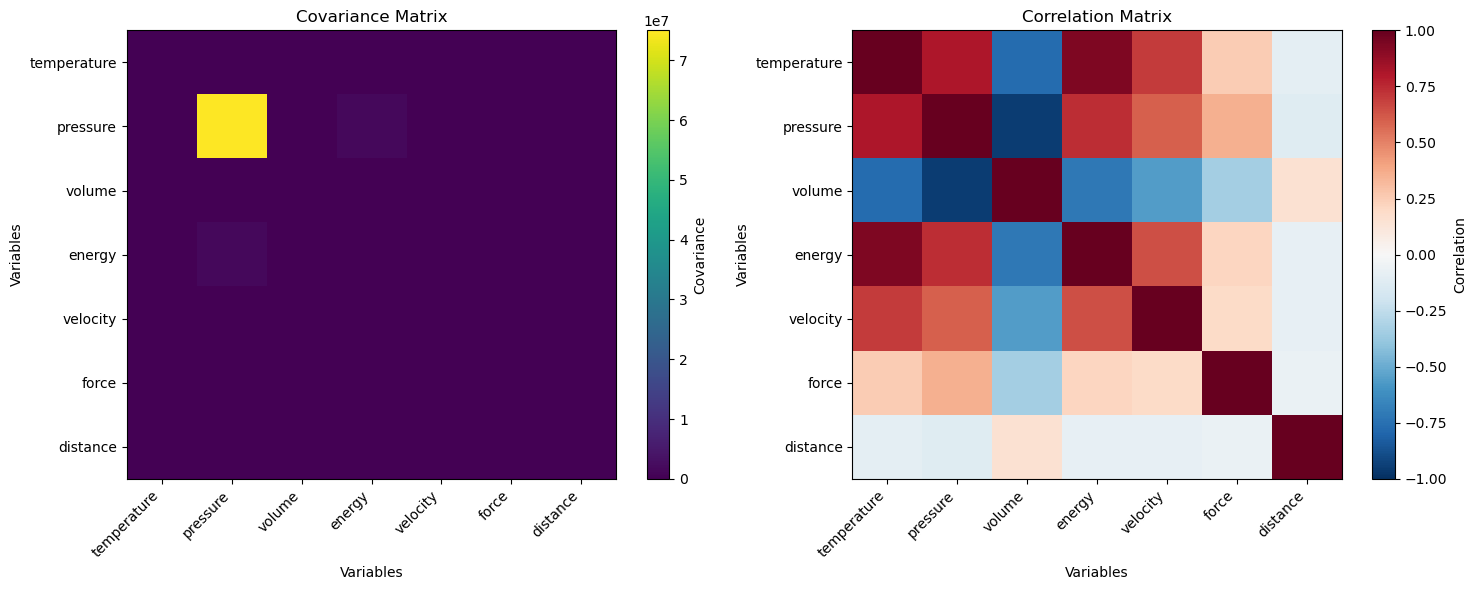

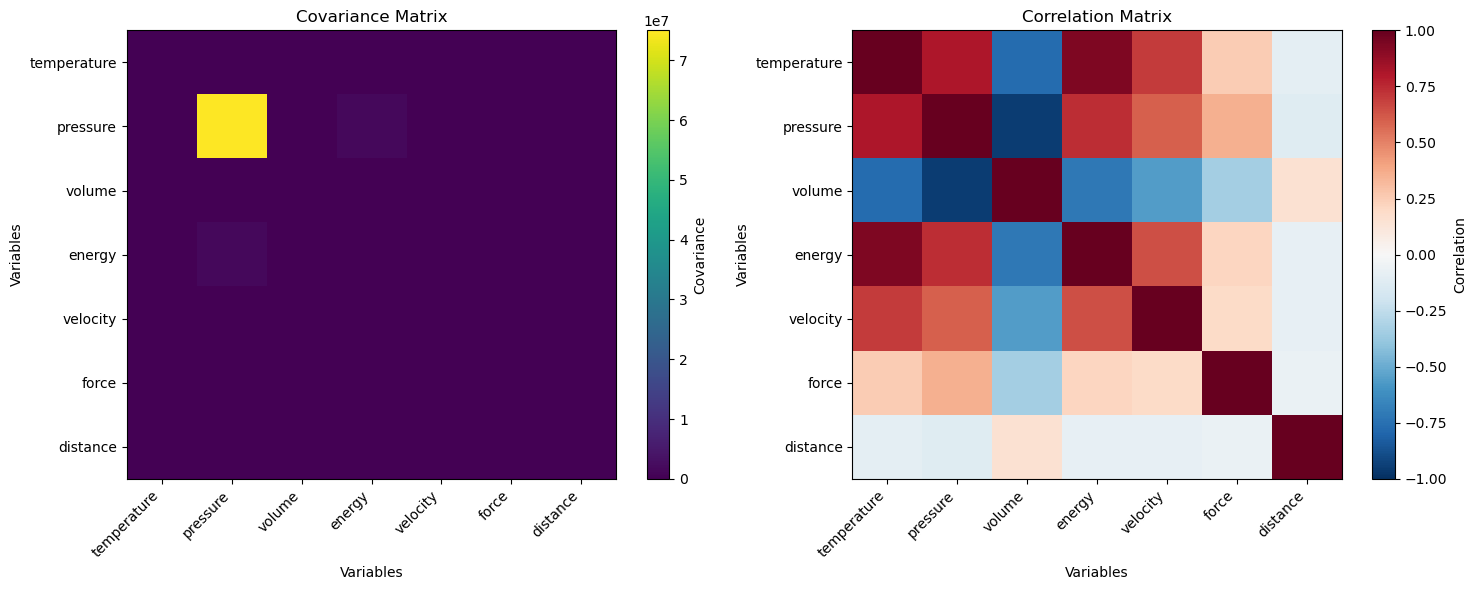

In [27]:
#showing the plot
plot_covariance_matrices("physics_data.csv", show_plot=True)

In [ ]:
grader.check("q3b")

## **Question 4**: Poisson Likelihood Estimation

The Poisson distribution is fundamental in physics for describing the probability of observing a discrete number of events (like photon counts, radioactive decays, or particle detections) in a fixed interval when events occur independently at a constant average rate.

The **Poisson probability mass function** for observing exactly $k$ events when the expected number is $\lambda$ is:

$$P(k|\lambda) = \frac{\lambda^k e^{-\lambda}}{k!}$$

When we have a dataset of $n$ independent observations $\{k_1, k_2, ..., k_n\}$, the **likelihood function** represents how probable it is to observe this specific dataset given a particular value of $\lambda$:

$$L(\lambda) = \prod_{i=1}^{n} P(k_i|\lambda) = \prod_{i=1}^{n} \frac{\lambda^{k_i} e^{-\lambda}}{k_i!}$$

For computational convenience, we often work with the **log-likelihood**:

$$\ln L(\lambda) = \sum_{i=1}^{n} \ln P(k_i|\lambda) = \sum_{i=1}^{n} \left[ k_i \ln(\lambda) - \lambda - \ln(k_i!) \right]$$

The **maximum likelihood estimate (MLE)** is the value of $\lambda$ that maximizes the likelihood function. For the Poisson distribution, the MLE has the analytical solution: $\hat{\lambda} = \bar{k} = \frac{1}{n}\sum_{i=1}^{n} k_i$ (the sample mean).

### Part a: Computing the Poisson Likelihood

Write a function `poisson_likelihood(data, lambda_val)` that computes the likelihood of observing the given data for a specific value of λ.

**Mathematical Steps:**
1. For each data point $k_i$, compute $P(k_i|\lambda) = \frac{\lambda^{k_i} e^{-\lambda}}{k_i!}$
2. Multiply all individual probabilities: $L(\lambda) = \prod_{i=1}^{n} P(k_i|\lambda)$

**Requirements:**
- Use the Poisson probability mass function to compute individual probabilities
- Return the product of all probabilities (the likelihood)
- Handle potential numerical underflow by using appropriate functions
- You may use `scipy.stats.poisson.pmf()` or implement the formula directly

**Parameters:**
- `data`: array-like, observed count data (integers)
- `lambda_val`: float, the Poisson parameter λ

**Returns:**
- `likelihood`: float, the likelihood L(λ) of observing the data given λ

**Hint:** For large datasets, likelihoods can become extremely small. Consider using `np.prod()` or working with log-likelihood and then exponentiating if needed.

In [31]:
def poisson_likelihood(data, lambda_val):
    # BEGIN SOLUTION NO PROMPT
    """
    Compute the likelihood of observing the given data for a Poisson distribution.
    
    Parameters:
    -----------
    data : array-like
        Observed count data (integers)
    lambda_val : float
        The Poisson parameter λ
    
    Returns:
    --------
    likelihood : float
        The likelihood L(λ) of observing the data given λ
    """
    from scipy.stats import poisson
    
    # Convert data to numpy array for convenience
    data = np.array(data)
    
    # Compute individual probabilities using Poisson PMF
    probabilities = poisson.pmf(data, lambda_val)
    
    # Likelihood is the product of all probabilities
    likelihood = np.prod(probabilities)
    
    return likelihood
    # END SOLUTION
    """ # BEGIN PROMPT
    from scipy.stats import poisson
    
    # Convert data to numpy array
    data = np.array(data)
    
    # Compute individual probabilities
    probabilities = ...
    
    # Compute likelihood as product of probabilities
    likelihood = ...
    
    return likelihood
    """; # END PROMPT

In [ ]:
grader.check("q4a")

### Part b: Likelihood Curve and Maximum Likelihood Estimation

Write a function `plot_likelihood_curve(data, lambda_range=None, n_points=100, show_plot=False)` that plots the likelihood function as a function of λ and determines the maximum likelihood estimate with confidence bounds.

**Mathematical Steps:**

1. **Create λ range**: If not provided, use a range around the sample mean
2. **Calculate likelihood curve**: For each λ value, compute L(λ) using your function from part (a)
3. **Find MLE**: The λ value that maximizes the likelihood
4. **Determine confidence bounds**: 
   - Find the maximum likelihood: $L_{\max} = L(\hat{\lambda})$
   - The 1σ confidence interval corresponds to $L(\lambda) = L_{\max} \times e^{-0.5}$ (where log-likelihood drops by 0.5)
   - Find the λ values where the likelihood curve crosses this threshold

**Requirements:**
- Use your `poisson_likelihood` function from part (a) to compute likelihoods
- Create a smooth curve by evaluating many λ values
- Plot the likelihood vs λ with appropriate labels and formatting
- Mark the MLE and confidence bounds on the plot
- Return the figure object and the three key values

**Parameters:**
- `data`: array-like, observed count data
- `lambda_range`: tuple (min, max), default None. If None, use (0.5*mean, 2*mean)
- `n_points`: int, default 100, number of λ values to evaluate
- `show_plot`: bool, default False. If True, call `plt.show()`

**Returns:**
- `(fig, mle, lower_bound, upper_bound)`: tuple containing:
  - `fig`: matplotlib figure object
  - `mle`: float, maximum likelihood estimate of λ
  - `lower_bound`: float, 1σ lower confidence bound
  - `upper_bound`: float, 1σ upper confidence bound

**Note:** For computational stability with small likelihoods, you may want to work with log-likelihood internally and convert back for plotting and analysis.

In [35]:
def plot_likelihood_curve(data, lambda_range=None, n_points=100, show_plot=False):
    # BEGIN SOLUTION NO PROMPT
    """
    Plot the likelihood function and find MLE with confidence bounds.
    
    Parameters:
    -----------
    data : array-like
        Observed count data
    lambda_range : tuple (min, max), default None
        Range of λ values to evaluate. If None, use (0.5*mean, 2*mean)
    n_points : int, default 100
        Number of λ values to evaluate
    show_plot : bool, default False
        If True, display the plot with plt.show()
    
    Returns:
    --------
    (fig, mle, lower_bound, upper_bound) : tuple
        Figure object, MLE, and 1σ confidence bounds
    """
    data = np.array(data)
    sample_mean = np.mean(data)
    
    # Set lambda range if not provided
    if lambda_range is None:
        lambda_min = max(0.1, 0.5 * sample_mean)  # Avoid zero
        lambda_max = 2.0 * sample_mean
        lambda_range = (lambda_min, lambda_max)
    
    # Create array of lambda values
    lambda_vals = np.linspace(lambda_range[0], lambda_range[1], n_points)
    
    # Calculate likelihood for each lambda value
    likelihoods = np.array([poisson_likelihood(data, lam) for lam in lambda_vals])
    
    # Find MLE (maximum likelihood estimate)
    max_idx = np.argmax(likelihoods)
    mle = lambda_vals[max_idx]
    max_likelihood = likelihoods[max_idx]
    
    # Find 1-sigma confidence bounds (likelihood drops by factor of e^(-0.5))
    threshold = max_likelihood * np.exp(-0.5)
    
    # Find indices where likelihood crosses the threshold
    above_threshold = likelihoods >= threshold
    valid_indices = np.where(above_threshold)[0]
    
    if len(valid_indices) > 0:
        lower_bound = lambda_vals[valid_indices[0]]
        upper_bound = lambda_vals[valid_indices[-1]]
    else:
        # Fallback if no valid bounds found
        lower_bound = mle - 0.1 * mle
        upper_bound = mle + 0.1 * mle
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot likelihood curve
    ax.plot(lambda_vals, likelihoods, 'b-', linewidth=2, label='Likelihood L(λ)')
    
    # Mark MLE
    ax.axvline(mle, color='red', linestyle='--', linewidth=2, 
               label=f'MLE: λ = {mle:.3f}')
    ax.plot(mle, max_likelihood, 'ro', markersize=8)
    
    # Mark confidence bounds
    ax.axvline(lower_bound, color='orange', linestyle=':', linewidth=2, alpha=0.8)
    ax.axvline(upper_bound, color='orange', linestyle=':', linewidth=2, alpha=0.8)
    ax.axhline(threshold, color='gray', linestyle=':', alpha=0.5, 
               label='1σ threshold')
    
    # Fill confidence region
    ax.fill_between(lambda_vals, 0, likelihoods, 
                    where=(lambda_vals >= lower_bound) & (lambda_vals <= upper_bound),
                    alpha=0.2, color='orange', label=f'1σ CI: [{lower_bound:.3f}, {upper_bound:.3f}]')
    
    # Formatting
    ax.set_xlabel('λ (Poisson parameter)')
    ax.set_ylabel('Likelihood L(λ)')
    ax.set_title(f'Poisson Likelihood Function\nData: {len(data)} observations, Sample mean: {sample_mean:.3f}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Set y-axis to start from 0 for better visualization
    ax.set_ylim(bottom=0)
    
    if show_plot:
        plt.show()
    
    return fig, mle, lower_bound, upper_bound
    # END SOLUTION
    """ # BEGIN PROMPT
    data = np.array(data)
    sample_mean = np.mean(data)
    
    # Set lambda range if not provided
    if lambda_range is None:
        lambda_range = ...
    
    # Create array of lambda values
    lambda_vals = ...
    
    # Calculate likelihood for each lambda value
    likelihoods = ...
    
    # Find MLE
    mle = ...
    
    # Find confidence bounds (likelihood drops by e^(-0.5))
    threshold = ...
    lower_bound = ...
    upper_bound = ...
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot likelihood curve and mark MLE and bounds
    ...
    
    if show_plot:
        plt.show()
    
    return fig, mle, lower_bound, upper_bound
    """; # END PROMPT

Generated 50 observations from Poisson(λ=4.2)
Sample data: [6 4 5 6 5 3 5 5 3 2]...
Sample mean: 4.300
Sample standard deviation: 2.002
Theoretical mean: 4.2
Theoretical std: 2.049

Testing likelihood function:
L(λ=3.0) = 1.44e-51
L(λ=4.0) = 2.02e-46
L(λ=5.0) = 2.66e-47


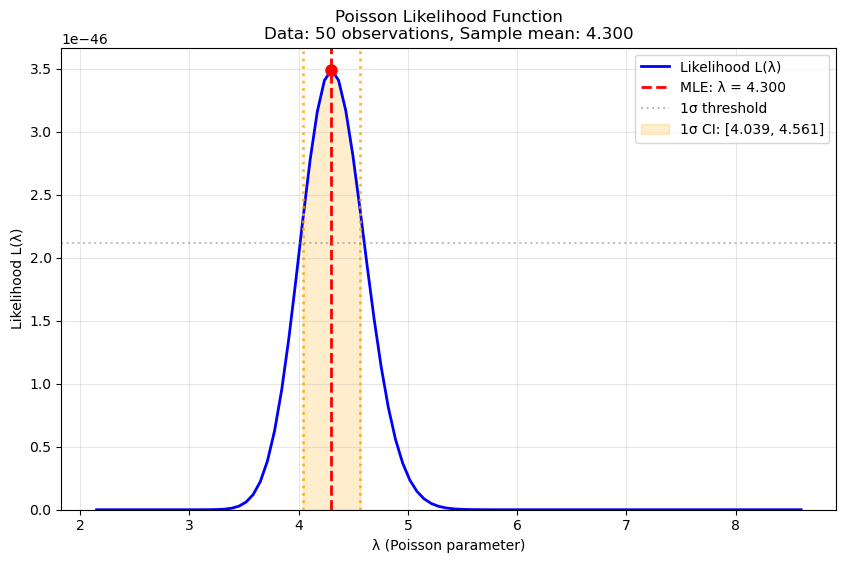


Results:
Maximum Likelihood Estimate: 4.300
1σ Confidence Interval: [4.039, 4.561]
True value λ=4.2 is within the confidence interval


In [36]:
# Generate sample Poisson data for testing
np.random.seed(rng_seed)

# Create a dataset with known Poisson parameter (lambda = 4.2)
true_lambda = 4.2
n_observations = 50
poisson_data = np.random.poisson(true_lambda, n_observations)

print(f"Generated {n_observations} observations from Poisson(λ={true_lambda})")
print(f"Sample data: {poisson_data[:10]}...")  # Show first 10 values
print(f"Sample mean: {np.mean(poisson_data):.3f}")
print(f"Sample standard deviation: {np.std(poisson_data):.3f}")
print(f"Theoretical mean: {true_lambda}")
print(f"Theoretical std: {np.sqrt(true_lambda):.3f}")

# Test the likelihood function with a few values
print(f"\nTesting likelihood function:")
test_lambdas = [3.0, 4.0, 5.0]
for lam in test_lambdas:
    likelihood = poisson_likelihood(poisson_data, lam)
    print(f"L(λ={lam}) = {likelihood:.2e}")

# Plot the likelihood curve
fig, mle, lower, upper = plot_likelihood_curve(poisson_data, show_plot=True)

print(f"\nResults:")
print(f"Maximum Likelihood Estimate: {mle:.3f}")
print(f"1σ Confidence Interval: [{lower:.3f}, {upper:.3f}]")
print(f"True value λ={true_lambda} is {'within' if lower <= true_lambda <= upper else 'outside'} the confidence interval")

In [ ]:
grader.check("q4b")

## Required disclosure of use of AI technology

Please indicate whether you used AI to complete this homework. If you did, explain how you used it in the python cell below, as a comment.

In [40]:
# BEGIN SOLUTION NO PROMPT
# END SOLUTION
""" # BEGIN PROMPT
"""
# write ai disclosure here:

"""
"""; # END PROMPT

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit.

Upload the .zip file to Gradescope!

In [ ]:
grader.export(pdf=False, force_save=True, run_tests=True)